In [2]:
import os 
import numpy as np
import pandas as pd
import json
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from src.setting import ExcludSubj, GetInfo, get_data_grp
from src.config import OUT_PATH, COL_REG
from src.decomposition import CompoThr
import mat73
from sklearn.manifold import Isomap, LocallyLinearEmbedding, MDS, SpectralEmbedding, TSNE

n_compo= 3
algorithms = {
    'Isomap': Isomap(n_components=n_compo), 
    'LLE' : LocallyLinearEmbedding(n_components=n_compo),
    'MDS' : MDS(n_components=n_compo),
    'SpectralEmbedding' : SpectralEmbedding(n_components=n_compo), 
    'TSNE' : TSNE(n_components=n_compo)

}

In [3]:
epoch_path = OUT_PATH + '/Data_longWOBS'
subj_included = [file.replace('_epochs.p', '') for file in os.listdir(epoch_path) if file[-len('epochs.p'):] == 'epochs.p']
subj_included = ExcludSubj(subj_included=subj_included, data_path=epoch_path)

coord, areas, elect_list, subj_list, region = GetInfo(subj_included, data_path=epoch_path)

print('Number of subject is ', len(subj_included))


Number of subject is  30


In [15]:
dataiEEG = get_data_grp(subj_included=subj_included, type_data='epoch', data_path=epoch_path)
iEEGPCAdata = pd.read_csv('/users/barbara/Desktop/MIB_iEEG/outs/grpPCA/supsubj_bb_mean/grp_Compo_PCA5.csv').drop(columns = ['Unnamed: 0', 'compo', 'freq']).values
data_iEEGfreq=get_data_grp(subj_included=subj_included, type_data='tfr', data_path=epoch_path)

In [16]:
file_path = '/users/barbara/Desktop/MIB_iEEG/MEG/Data_Example.mat'
MEGdata = mat73.loadmat(file_path)
MEGdata = MEGdata['data'][:, :, :2]
MEGPCAdata = pd.read_csv('/users/barbara/Desktop/MIB_iEEG/MEG/MEG_componants.csv').drop(columns =['Unnamed: 0']).values

## Joint emmbedding frequences

In [52]:
theta_lat = data_iEEGfreq[:, :, 1, :].mean(0)
hg_lat = data_iEEGfreq[:, :, -1, :].mean(0)

PCA_theta = pd.read_csv('/users/barbara/Desktop/MIB_iEEG/outs/grpPCA/supsubj_concat/grp_concat_Compo_PCA5.csv').query('freq == "theta"').drop(columns = ['Unnamed: 0', 'compo', 'freq']).values
PCA_hg= pd.read_csv('/users/barbara/Desktop/MIB_iEEG/outs/grpPCA/supsubj_concat/grp_concat_Compo_PCA5.csv').query('freq == "high_gamma"').drop(columns = ['Unnamed: 0', 'compo', 'freq']).values

In [96]:
Z_hg = {}
for algo_name, algo in algorithms.items() : 
    Z_hg[algo_name] = algo.fit_transform(hg_lat)

/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


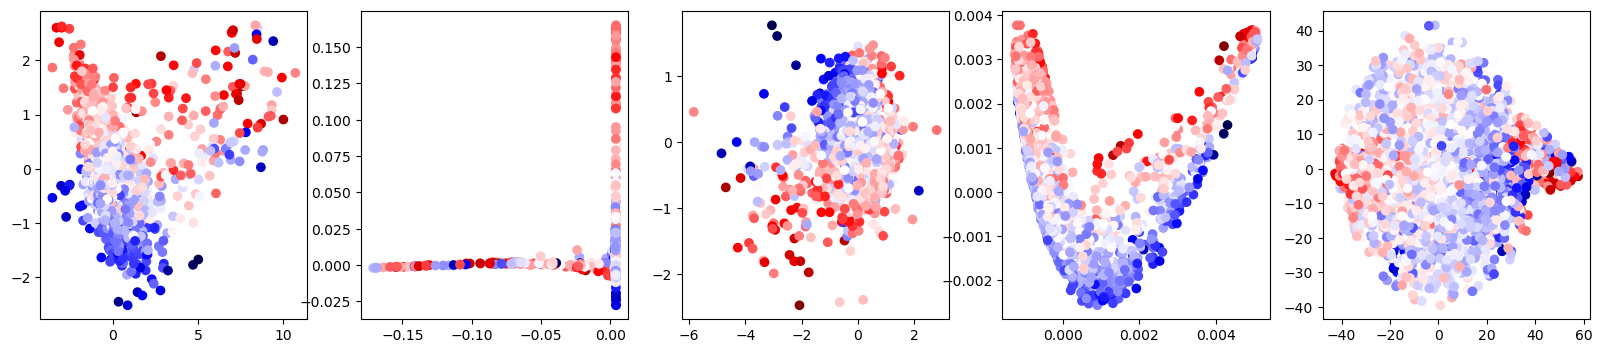

In [102]:
fig, ax=plt.subplots(1, len(algorithms.keys()), figsize=(20, 4))

for i, algo in enumerate(list(algorithms.keys())):
    ax[i].scatter(Z_hg[algo][:, 0], Z_hg[algo][:, 2], c=PCA_hg[2, :], cmap='seismic')

In [103]:
X_joint = np.concatenate([theta_lat, hg_lat],axis=1)

Z_joint = {}
for algo_name, algo in algorithms.items() : 
    Z_joint[algo_name] = algo.fit_transform(X_joint)

/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


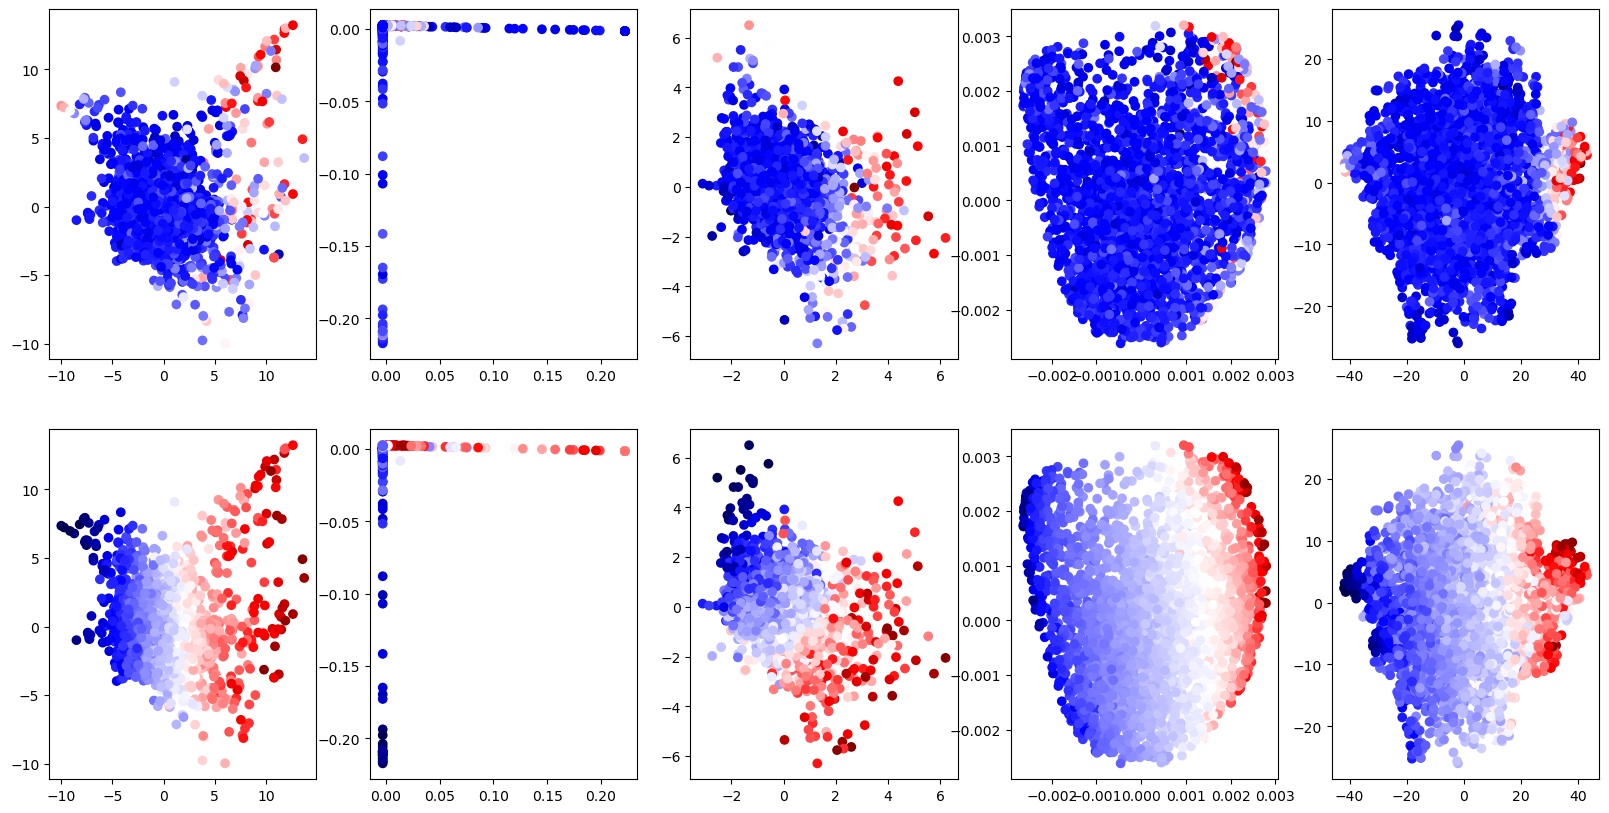

In [111]:
# Theta 1 and high gamma 0 (sensory processing) projected into the same embedding space
fig, ax=plt.subplots(2, len(algorithms.keys()), figsize=(20, 10))

for i, algo in enumerate(list(algorithms.keys())):
    ax[0][i].scatter(Z_joint[algo][:, 0], Z_joint[algo][:, 1], c=PCA_hg[0, :], cmap='seismic')
    ax[1][i].scatter(Z_joint[algo][:, 0], Z_joint[algo][:, 2], c=PCA_theta[0, :], cmap='seismic')

In [1]:
# PCA embedding space
fig = plt.figure()
#ax = fig.add_subplot(projection='3d')
#ax.scatter(PCA_hg[0, :], PCA_hg[1, :],PCA_hg[2, :], c=PCA_theta[0, :], cmap='seismic', )
plt.scatter(PCA_theta[0, :], PCA_theta[1, :], c=PCA_hg[2, :], cmap='seismic', s=4)


NameError: name 'plt' is not defined

## By RIOs


In [47]:
df= pd.DataFrame(region, columns = ['region'])
memory_regions = ['HPC','PHC','EC','PCC','PRH']
memory_rois = df[df['region'].isin(memory_regions)].index
color_regions = df[df['region'].isin(memory_regions)].region.astype("category").cat.codes.values
data_rois = data_iEEGfreq[:, memory_rois, 1, :]

In [48]:
X_rois0 = {}
X_rois1={}

for algo_name, algo in algorithms.items() : 
    X_rois0[algo_name] = algo.fit_transform(data_rois[0, :, :])
    X_rois1[algo_name] = algo.fit_transform(data_rois[1, :, :])

/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Text(0, 0.5, 'NEW')

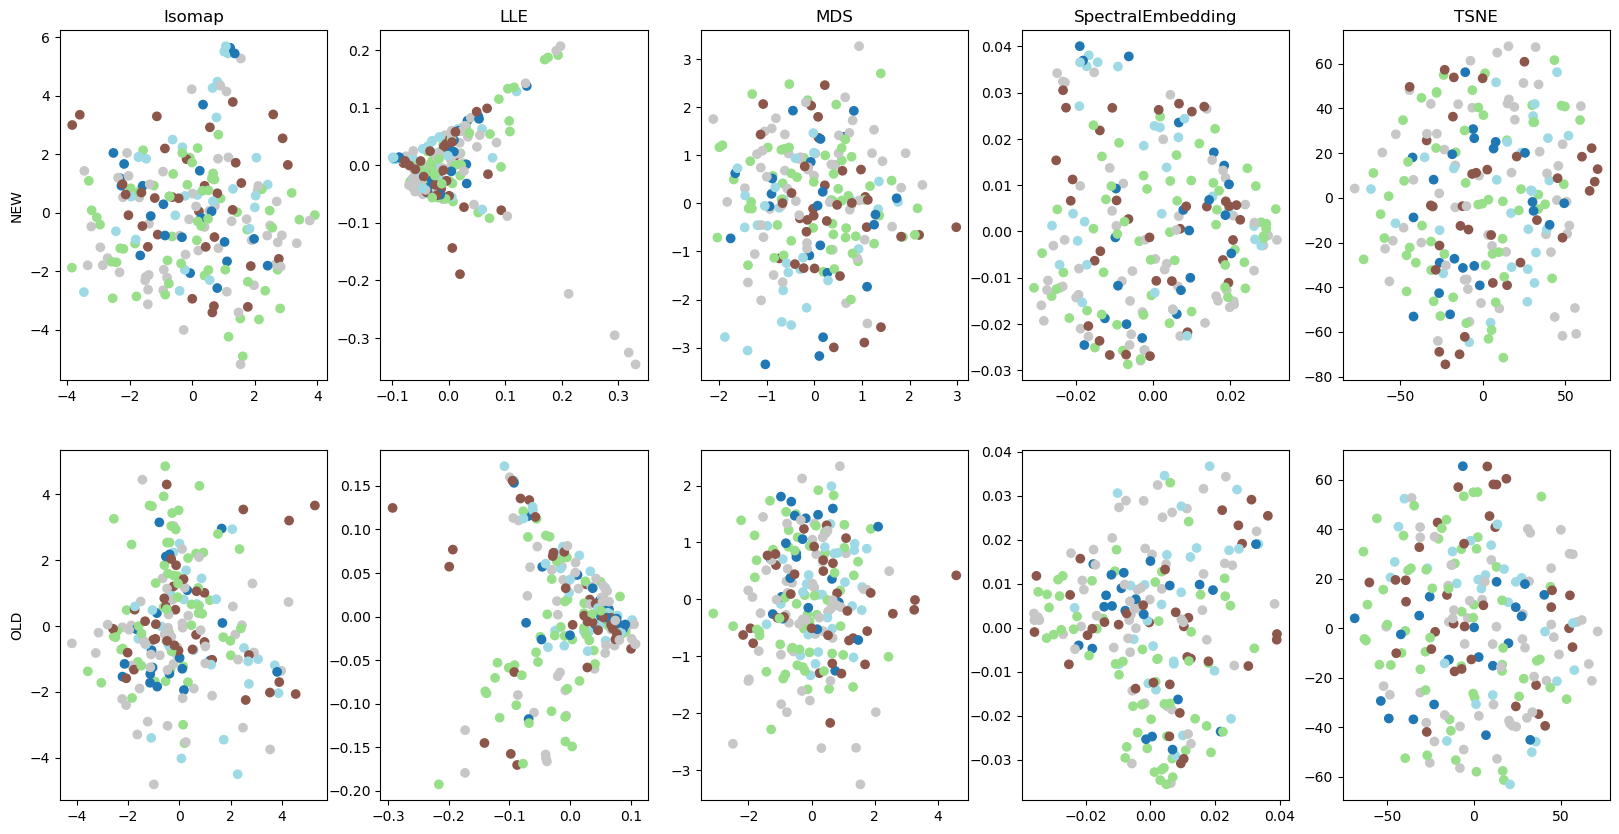

In [50]:
fig, ax = plt.subplots(2, len(algorithms), figsize=(20, 10)) 

for i, algo in enumerate(list(algorithms.keys())) : 
    ax[0, i].scatter(X_rois0[algo][:, 1], X_rois0[algo][:, 0], c=color_regions, cmap ='tab20')
    ax[1, i].scatter(X_rois1[algo][:, 1], X_rois1[algo][:, 0], c=color_regions, cmap='tab20')
    ax[0, i].set_title(algo)
ax[1, 0].set_ylabel('OLD')
ax[0, 0].set_ylabel('NEW')



## Compare MEG

In [93]:
X_transMEG = {}
X_transiEEG = {}

for algo_name, algo in algorithms.items() : 
    X_transMEG[algo_name] = algo.fit_transform(MEGdata.mean(2))
    X_transiEEG[algo_name] = algo.fit_transform(dataiEEG.mean(0))

/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Text(0, 0.5, 'Componant1')

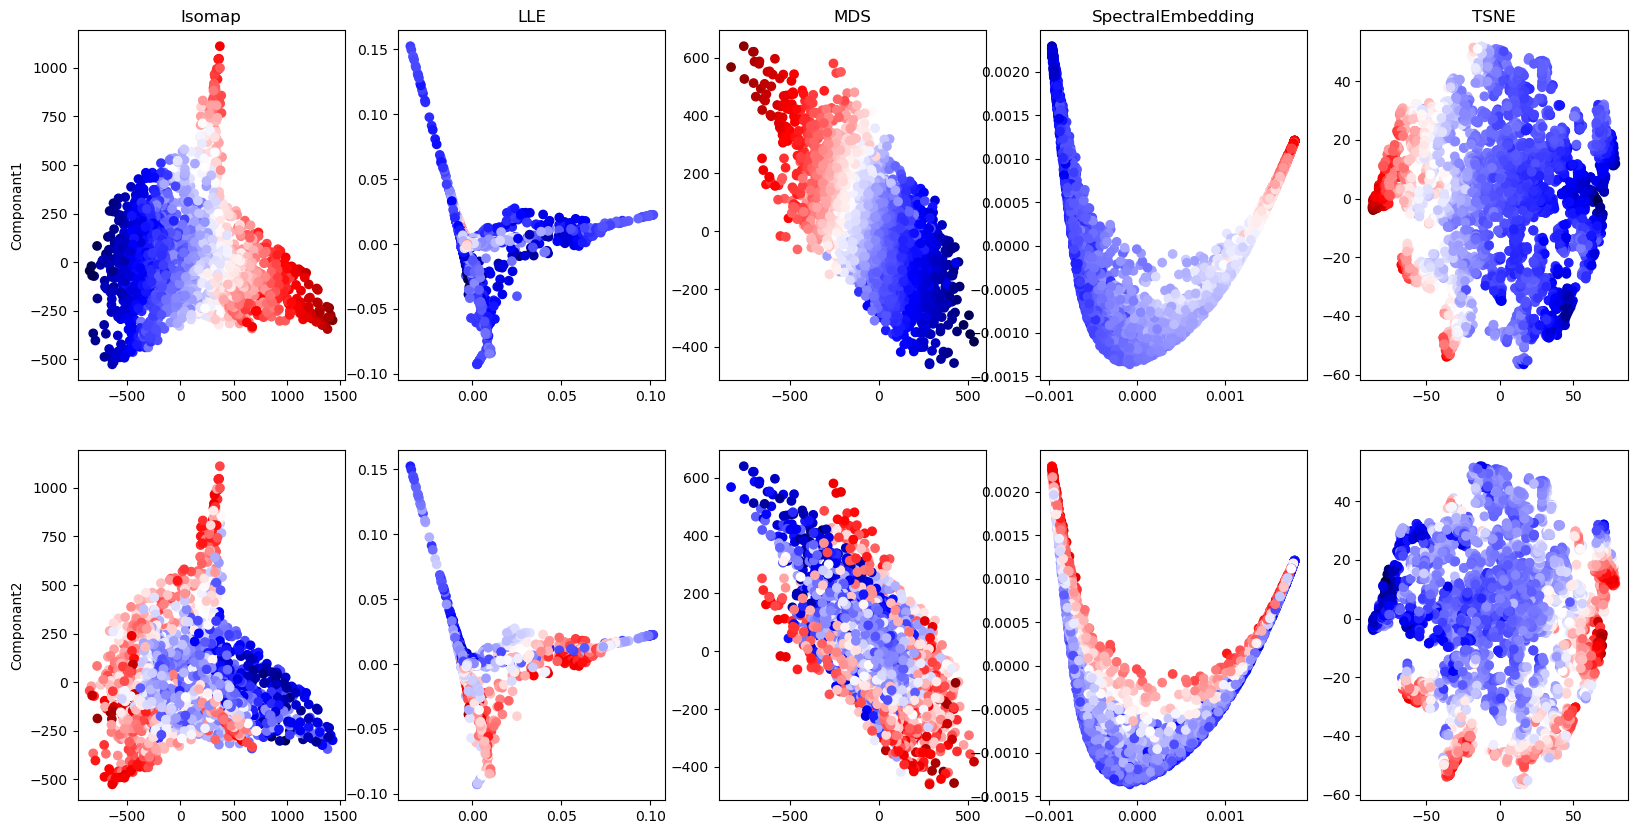

In [94]:
fig, ax = plt.subplots(2, len(algorithms), figsize=(20, 10)) 

for i, algo in enumerate(list(algorithms.keys())) : 
    ax[0, i].scatter(X_transMEG[algo][:, 0], X_transMEG[algo][:, 1], c=MEGPCAdata[0, :], cmap ='seismic')
    ax[1, i].scatter(X_transMEG[algo][:, 0], X_transMEG[algo][:, 1], c=MEGPCAdata[1, :], cmap='seismic')
    
    ax[0, i].set_title(algo)
ax[1, 0].set_ylabel('Componant2')
ax[0, 0].set_ylabel('Componant1')

Text(0, 0.5, 'Componant1')

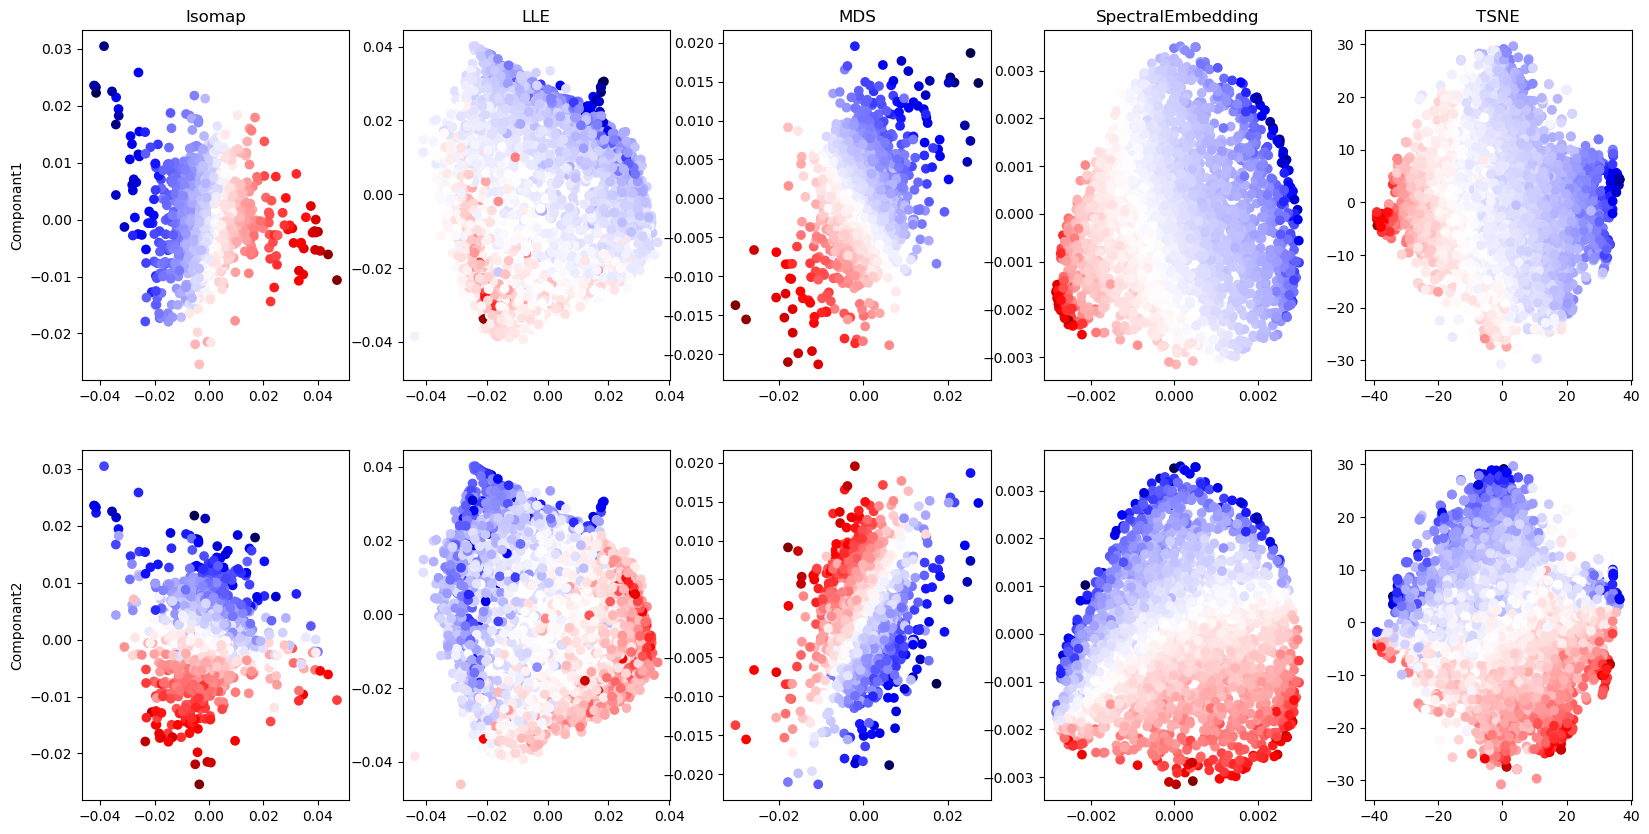

In [75]:
fig, ax = plt.subplots(2, len(algorithms), figsize=(20, 10)) 

for i, algo in enumerate(list(algorithms.keys())) : 
    ax[0, i].scatter(X_transiEEG[algo][:, 0], X_transiEEG[algo][:, 1], c=iEEGPCAdata[0, :], cmap ='seismic')
    ax[1, i].scatter(X_transiEEG[algo][:, 0], X_transiEEG[algo][:, 1], c=iEEGPCAdata[1, :], cmap='seismic')
    ax[0, i].set_title(algo)
ax[1, 0].set_ylabel('Componant2')
ax[0, 0].set_ylabel('Componant1')



- Continuous gradients in the t-SNE colored by PC weights: the local neighborhoods preserved by t-SNE are aligned with the dominant variance captured by PCA.
- Similar color gradients in MEG and iEEG t-SNE spaces may suggest that both modalities share a similar low-dimensional organization.

## Joint embbeding MEG iEEG

In [89]:
# SHOULD HAVE THE SAME SAMPLING RATE !!!!
MEGdata.mean(2), dataiEEG.mean(0)

In [91]:
# PCA then tSNE
meg_lat = PCA(50).fit_transform(MEGdata.mean(2).T)
ieeg_lat = PCA(50).fit_transform(dataiEEG.mean(0).T)

X_joint = np.concatenate(
    [meg_lat, ieeg_lat],
    axis=1
)

Z = TSNE().fit_transform(X_joint)


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 776 and the array at index 1 has size 1000

## Manifold comparison